<a href="https://colab.research.google.com/github/Evelynrodrigues28/Analise-performance-vendas/blob/main/An%C3%A1lise_de_Performance_de_Vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importação das bibliotecas

In [ ]:
#Importação das bibliotecas para manipulação e visualização dos dados
import pandas as pd
import matplotlib.pyplot as plt

#Leitura da base de dados

In [79]:
#Leitura do arquivo CSV contendo os dados de vendas
df = pd.read_csv('base_python.csv')
#Carregamento das 10 primeiras linhas para visualização da estrutura do arquivo
df.head(10)

,Distribuidor,Valor da venda,Quantidade vendida,Produto,Data da venda
0,Distribuidora Alfa,123.50,20,Snickers,2026-01-05
1,Distribuidora Beta,98.00,15,Skittles,2026-01-07
2,Distribuidora Gama,150.75,25,Twix,2026-01-09
3,Distribuidora Delta,110.00,18,M&M's,2026-01-10
4,Distribuidora Alfa,95.20,13,Snickers,2026-01-12
5,Distribuidora Beta,130.00,22,Skittles,2026-01-13
6,Distribuidora Gama,115.50,19,Twix,2026-01-15
7,Distribuidora Delta,140.00,24,M&M's,2026-01-16
8,Distribuidora Alfa,105.00,16,Snickers,2026-01-18
9,Distribuidora Beta,120.00,20,Skittles,2026-01-19


#Total por Distribuidor

In [69]:
# Cálculo do valor total vendido e da quantidade total vendida
# Ordenação decrescente pelo valor total vendido para criação do ranking

Total_por_Distribuidor = (
    df.groupby("Distribuidor", as_index=False)[["Valor da venda", "Quantidade vendida"]]
      .sum()
      .sort_values(by="Valor da venda", ascending=False)
)

Total_por_Distribuidor

,Distribuidor,Valor da venda,Quantidade vendida
2,Distribuidora Delta,3345.00,518
0,Distribuidora Alfa,3278.70,509
3,Distribuidora Gama,3216.25,493
1,Distribuidora Beta,3103.00,473


#Identificação do prestador com maior valor vendido e produto com maior quantidade vendida

In [70]:
# Distribuidor com maior valor vendido
Melhor_Distribuidor = df.groupby("Distribuidor")["Valor da venda"].sum().idxmax()

#Produto com maior quantidade vendida
Produto_mais_vendido = df.groupby("Produto")["Quantidade vendida"].sum().idxmax()


print("Melhor distribuidor:", Melhor_Distribuidor)
print("Produto mais Vendido:", Produto_mais_vendido)

Melhor distribuidor: Distribuidora Delta
Produto mais Vendido: M&M's


#Gráfico Ranking por Valor de Venda

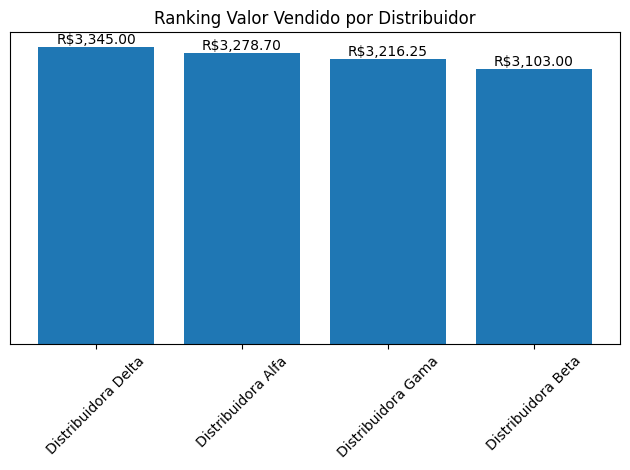

In [76]:

# Criação da figura para visualização do ranking de valor
plt.figure()
# Construção do gráfico de colunas com o valor total vendido por distribuidor
plt.bar(Total_por_Distribuidor["Distribuidor"], Total_por_Distribuidor["Valor da venda"])
# Rotação dos nomes no eixo X para melhor leitura
plt.xticks(rotation=45)
# Definição do título do gráfico
plt.title("Ranking Valor Vendido por Distribuidor")
# Remoção dos valores do eixo Y para visual mais limpo
plt.yticks([])

# Inclusão dos rótulos de valor no topo de cada coluna
for i, valor in enumerate(Total_por_Distribuidor["Valor da venda"]):
  plt.text(i, valor, f"R${valor:,.2f}", ha="center", va="bottom")

# Ajuste automático do layout
plt.tight_layout()
# Exibição do gráfico
plt.show()

#Gráfico Ranking por quantidade de produtos vendidos

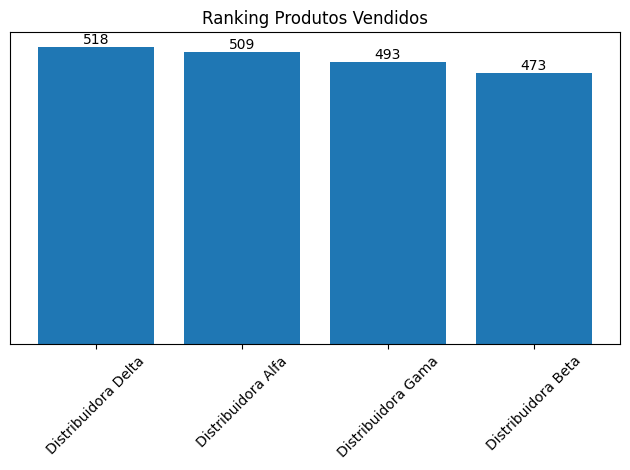

In [80]:
# Criação da figura para visualização do ranking de produtos
plt.figure()
# Construção do gráfico de colunas com o total de produto vendido por distribuidor
plt.bar(Total_por_Distribuidor["Distribuidor"], Total_por_Distribuidor["Quantidade vendida"])
# Rotação dos nomes no eixo X para melhor leitura
plt.xticks(rotation=45)
# Definição do título do gráfico
plt.title("Ranking Produtos Vendidos")
# Remoção dos valores do eixo Y para visual mais limpo
plt.yticks([])
# Inclusão dos rótulos de quantidade no topo de cada coluna
for i, valor in enumerate(Total_por_Distribuidor["Quantidade vendida"]):
  plt.text(i, valor, f"{valor:,.0f}", ha="center", va="bottom")

# Ajuste automático do layout
plt.tight_layout()
# Exibição do gráfico
plt.show()